#**Regresi Linear**

## **Deskripsi Kasus**

**Konteks:** Sebuah perusahaan properti ingin memprediksi harga rumah di pasaran berdasarkan karakteristik fisik dan lokasinya. Prediksi harus dibuat secara akurat agar perusahaan dapat mengestimasi valuasi properti dengan tepat.  

**Variabel:** Berdasarkan dataset yang diberikan, variabel independen (fitur) yang digunakan sebagai prediktor meliputi: luas bangunan dalam m2, jumlah kamar, jumlah kamar mandi, jarak ke pusat kota dalam km, usia rumah dalam tahun, dan kapasitas garasi. Sementara itu, variabel dependen (target) yang akan diprediksi adalah harga rumah dalam juta Rupiah.  

**Tujuan:** Analisis memiliki tiga tujuan, yaitu:
1. Membangun dan memahami penerapan model regresi linier
2. Menganalisis bagaimana keberadaan outlier memengaruhi kinerja model
3. Mengevaluasi dan membandingkan ketahanan antara model Multiple Linear Regression konvensional dengan Huber Regression.

**Tantangan Utama:** Tantangan terbesar dalam pemodelan data ini adalah keberadaan outlier pada variabel target. Berdasarkan dataset, terdapat beberapa data rumah dengan label harga "terlalu_tinggi" atau "terlalu_rendah" yang menyimpang jauh dari tren populasi normal. Karena regresi linier sangat sensitif terhadap outlier, hal ini berpotensi merusak akurasi prediksi secara keseluruhan.

## **Exploratory Data Analysis (EDA)**

**Deskripsi Database**

Nama Database : dataset_regresi_linier_rumah.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [ ]:
#Load Database
#Upload CSV ke Google Colab
df = pd.read_csv('dataset_regresi_linier_rumah.csv')
#Cek Statistik Deskriptif
df.describe()

,luas_bangunan_m2,jumlah_kamar,jumlah_kamar_mandi,jarak_ke_pusat_kota_km,usia_rumah_tahun,kapasitas_garasi,harga_rumah_juta_rp
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,119.985833,3.104167,2.395833,11.816208,13.770833,0.995833,1189.199833
std,33.806620,1.489708,1.126694,5.857357,8.683634,0.789565,356.586277
min,45.000000,1.000000,1.000000,1.000000,0.000000,0.000000,337.000000
25%,96.007500,2.000000,1.000000,7.742500,6.775000,0.000000,988.762500
50%,122.180000,3.000000,2.000000,11.475000,14.300000,1.000000,1189.290000
75%,140.757500,5.000000,3.000000,15.492500,20.325000,2.000000,1368.157500
max,254.850000,5.000000,4.000000,28.700000,35.200000,2.000000,3114.310000


In [ ]:
#Cek Missing Value
df.isnull().sum()

,0
id_rumah,0
luas_bangunan_m2,0
jumlah_kamar,0
jumlah_kamar_mandi,0
jarak_ke_pusat_kota_km,0
usia_rumah_tahun,0
kapasitas_garasi,0
harga_rumah_juta_rp,0
label_outlier_harga,0


In [ ]:
#Cek Statistik Outlier Harga Rumah
Q1 = df['harga_rumah_juta_rp'].quantile(0.25)
Q3 = df['harga_rumah_juta_rp'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['harga_rumah_juta_rp'] < lower_bound) |
              (df['harga_rumah_juta_rp'] > upper_bound)]

print("Jumlah outlier:", len(outliers))

Jumlah outlier: 9


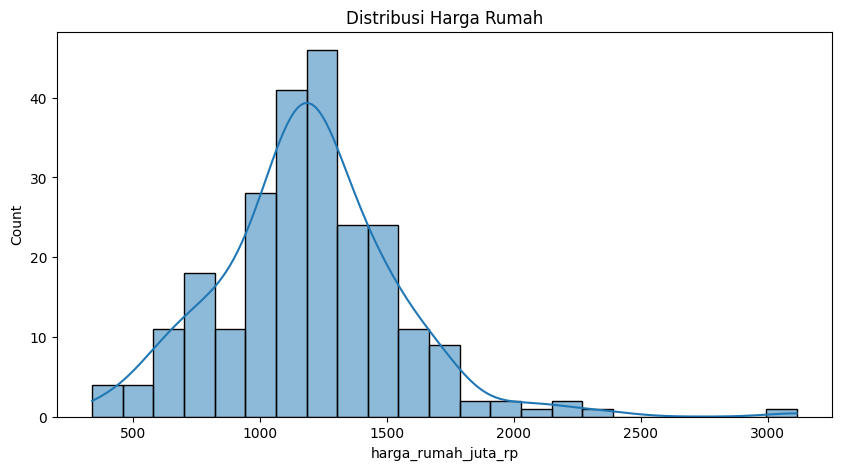

In [ ]:
#Visualisasi Distribusi Harga Rumah
plt.figure(figsize=(10,5))
sns.histplot(df['harga_rumah_juta_rp'], kde=True)
plt.title("Distribusi Harga Rumah")
plt.show()

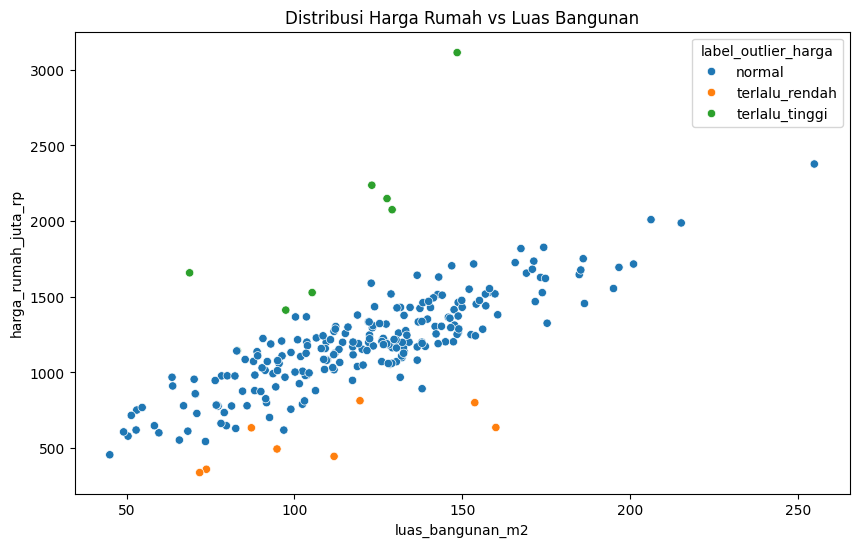

In [ ]:
#Visualisasi Distribusi Harga Rumah vs Luas Bangunan untuk Deteksi Outlier
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='luas_bangunan_m2', y='harga_rumah_juta_rp', hue='label_outlier_harga')
plt.title('Distribusi Harga Rumah vs Luas Bangunan')
plt.show()

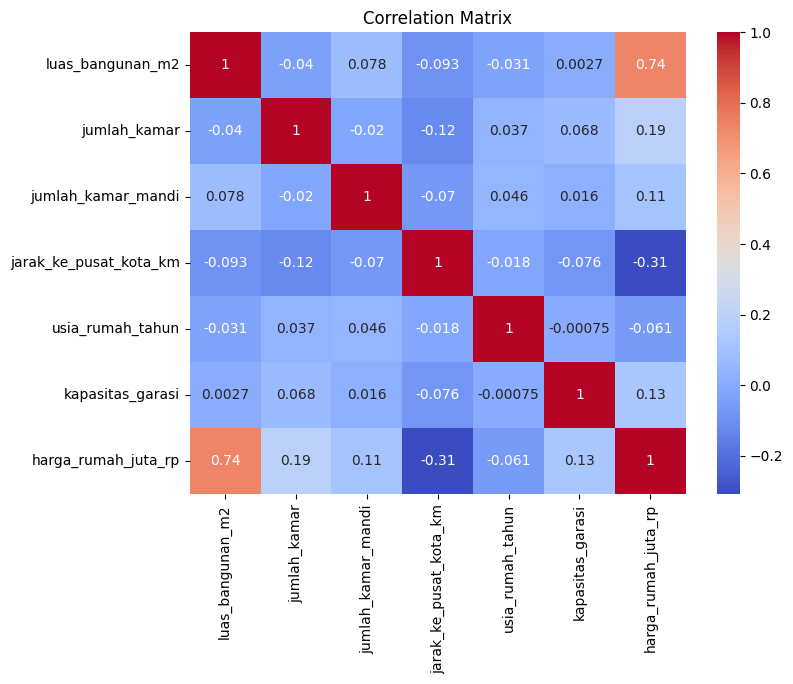

In [ ]:
#Visualisasi Correlation Matrix per Fitur
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

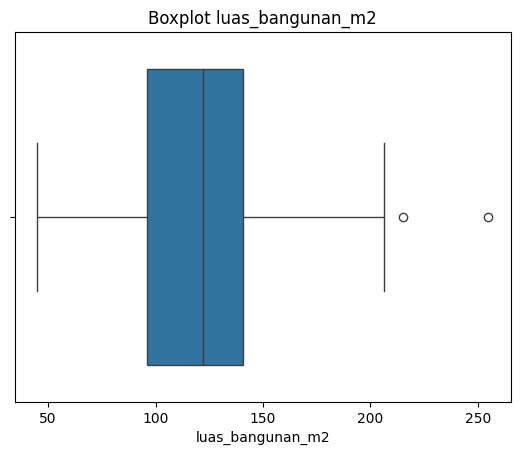

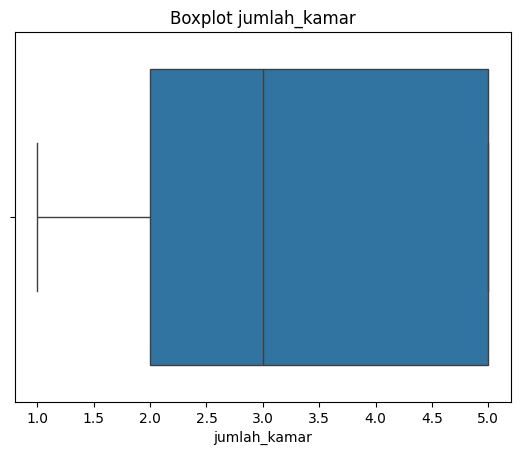

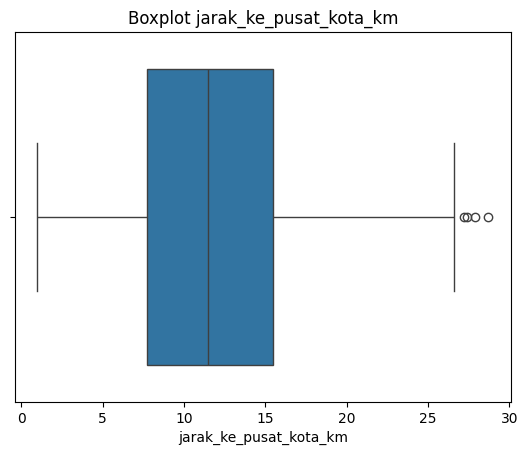

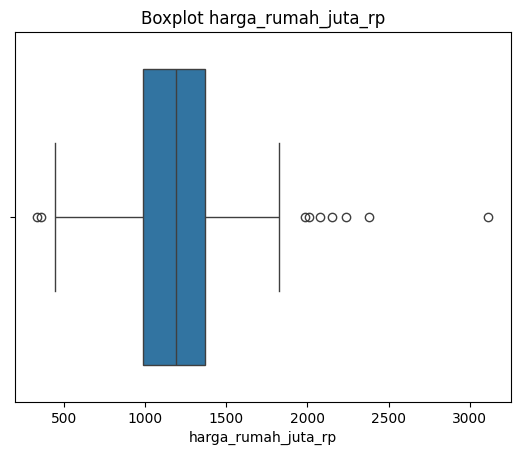

In [ ]:
#Visualisasi Boxplot per Fitur untuk mendeteksi Outlier
features = ['luas_bangunan_m2', 'jumlah_kamar', 'jarak_ke_pusat_kota_km', 'harga_rumah_juta_rp']

for col in features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

**Insight EDA**

a. Deskripsi : Terdapat 240 data, dengan 9 fitur yaitu,
1. luas_bangunan_m2
2. jumlah_kamar
3. jumlah_kamar_mandi
4. jarak_ke_pusat_kota_km
5. usia_rumah_tahun
6. kapasitas_garasi
7. harga_rumah_juta_rp
8. label_outlier_harga

b. Tidak ada Missing Value yang terdeteksi

c. Hubungan (Korelasi) antar Fitur
1. Berdasarkan Correlation Matrix, luas bangunan memiliki korelasi positif paling kuat terhadap harga rumah dengan nilai 0.74. Ini berarti semakin luas bangunan, harga rumah akan semakin tinggi secara signifikan.
2. Fitur jarak_ke_pusat_kota_km memiliki korelasi negatif sebesar -0.31 terhadap harga rumah. Karena semakin jauh sebuah rumah dari pusat kota, harganya cenderung semakin murah.
3. Fitur lain seperti usia rumah memiliki pengaruh korelasi yang sangat kecil (hampir mendekati nol, yakni -0.061) terhadap harga.

d. Distribusi & Outlier
1. Histogram menunjukkan distribusi harga rumah sedikit right-skewed, dimana mayoritas rumah berada di kisaran harga menengah ke bawah (sekitar 1000 - 1500 juta Rupiah), namun ada beberapa rumah yang harganya sangat tinggi hingga mendekati 3000 juta Rupiah.
2. Menggunakan metode Interquartile Range (IQR), terdeteksi ada 9 outlier pada kolom harga rumah
3. Pada visualisasi scatterplot, terlihat jelas adanya outlier di beberapa titik data diberi label "terlalu_tinggi" dan "terlalu_rendah"
4. Melalui visualisasi boxplot, selain pada harga, nilai outlier juga ditemukan pada fitur luas_bangunan_m2 dan jarak_ke_pusat_kota_km


## **Preprocessing**

In [ ]:
#Menentukan Fitur dan Target
#Fitur : Drop Kolom yang Tidak Digunakan
X = df.drop(columns=['id_rumah', 'harga_rumah_juta_rp', 'label_outlier_harga'], axis=1)

#Target
y = df['harga_rumah_juta_rp']

print("Fitur:", X.columns)
print("Jumlah fitur:", len(X.columns))

Fitur: Index(['luas_bangunan_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
       'jarak_ke_pusat_kota_km', 'usia_rumah_tahun', 'kapasitas_garasi'],
      dtype='object')
Jumlah fitur: 6


In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Jumlah data train:", X_train.shape)
print("Jumlah data test:", X_test.shape)

Jumlah data train: (192, 6)
Jumlah data test: (48, 6)


In [ ]:
#Standardisasi
scaler = StandardScaler()

# Fit pada data train
X_train_scaled = scaler.fit_transform(X_train)

# Transform data test
X_test_scaled = scaler.transform(X_test)

In [ ]:
pd.DataFrame(X_train_scaled, columns=X.columns).describe()

,luas_bangunan_m2,jumlah_kamar,jumlah_kamar_mandi,jarak_ke_pusat_kota_km,usia_rumah_tahun,kapasitas_garasi
count,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02
mean,-5.828671e-16,8.326673e-17,1.572816e-16,-6.938894e-17,-1.734723e-16,6.707597e-17
std,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00
min,-2.219875e+00,-1.492256e+00,-1.286919e+00,-1.833684e+00,-1.562786e+00,-1.238989e+00
25%,-7.408307e-01,-8.084540e-01,-1.286919e+00,-6.767907e-01,-7.737193e-01,-1.238989e+00
50%,7.147138e-02,-1.246515e-01,-3.785056e-01,-4.536305e-02,6.193394e-02,2.636147e-02
75%,6.517292e-01,1.242953e+00,5.299078e-01,6.173320e-01,7.228861e-01,1.291712e+00
max,3.947890e+00,1.242953e+00,1.438321e+00,2.978020e+00,2.536865e+00,1.291712e+00


**Analisis Preprocessing**
1. Saya menentukan variabel fitur yaitu dengan cara mendrop variabel 'id_rumah', 'harga_rumah_juta_rp', 'label_outlier_harga', karena *id* tidak terlalu penting dalam proses modelling, dan *harga_rumah_juta_rp* akan dijadikan variabel target dan *label_outlier_harga* adalah sebagai variabel tambahakan dan kurang relevan pada proses selanjutnya
2. Saya membagi data untuk train dan test dengan komposisi data training (80%) untuk melatih model dan data test (20%) untuk evaluasi model agar model tidak terlalu overfitting / underfitting dengan random state 42 agar hasil reproducible.
3. Standardisasi saya lakukan dengan scaling karena beberapa fitur memiliki skala berbeda, seperti luas_bangunan(puluhan–ratusan),
jarak_ke_pusat_kota (kecil), sehingga tidak balance. Scaling ini dilakukan setelah spliting agar tidak data leakage, dan fit hanya dilakukan untuk data train, tidak dengan data test.
4. Terlihat bahwa STD sudah mendekati angka 1 dan mean yang mendekati angka 0, dimana artinya data sudah terstandardisasi dengan baik.

## **Modeling**

###**Multiple Linear Regression**

In [ ]:
#Inisialisasi Model
lr_model = LinearRegression()
#Training Model
lr_model.fit(X_train_scaled, y_train)
#Prediksi Model
y_pred_lr = lr_model.predict(X_test_scaled)

In [ ]:
#Regularisasai pada MLR
ridge = Ridge()

param_grid_ridge = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    ridge,
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_ridge.fit(X_train_scaled, y_train)

print("Best alpha (Ridge):", grid_ridge.best_params_)

Best alpha (Ridge): {'alpha': 10}


In [ ]:
#Predict model dengan regularisasi Best Ridge
ridge_best = grid_ridge.best_estimator_
y_pred_ridge = ridge_best.predict(X_test_scaled)

**Analisis Multiple Linear Regression**

Multiple Linear Regression diawal dengan inisialisasi model, dengan memanggil pada library pada scikit-learn. Dilanjutkan dengan training model pada dataset train yang sudah di scaling, dan memprediksi model pada dataset test yang sudah di scaling. Tujuan dari model ini adalah untuk mencari hubungan linier antara fitur dan target.

Pada Multiple Linear Regression tandar yang menggunakan metode Ordinary Least Squares (OLS) sebenarnya tidak memiliki hyperparameter yang bisa di-tune. Namun, saya tuning dilakukan melalui pendekatan *regularisasi* dengan menggunakan Ridge, agar fitur lebih stabil.

Penggunaan Grid Search untuk mencari alpha terbaik karena Ridge hanya berurusan dengan penalti ukuran koefisien.

###**Huber Regression**

In [ ]:
#Inisialisasi Model
huber_model = HuberRegressor()

#Training Data
huber_model.fit(X_train_scaled, y_train)

#Prediksi Data
y_pred_huber = huber_model.predict(X_test_scaled)

In [ ]:
param_grid = {
    'epsilon': [1.1, 1.35, 1.5],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [100, 200]
}

grid = GridSearchCV(
    HuberRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'alpha': 0.01, 'epsilon': 1.35, 'max_iter': 100}


In [ ]:
#Predict model dengan best gridSearch
best_huber = grid.best_estimator_

# Prediksi
y_pred_huber_tuned = best_huber.predict(X_test_scaled)

**Analisis Huber Regression**

Huber Regression adalah robust regression, dimana diawal dengan inisialisasi model, dengan memanggil pada library pada scikit-learn. Dilanjutkan dengan training model pada dataset train yang sudah di scaling, dan memprediksi model pada dataset test yang sudah di scaling. Tujuan dari model ini adalah untuk mencari hubungan linier antara fitur dan target.

Hyperparamenter tuning dilakukan pada model Huber Regression dengan menggunakan Grid Search. Pada Grid Search digunakan parameter epsilon untuk menentukan batas outlier, alpha untuk regularisasi, dan max_iter untuk jumlah iterasi. Sehingga, Grid Search ini akan mengeluarkan kombinasi terbaik dari ketiga parameter untuk mencapai hasil maksimal.


## **Evaluation**

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

results = []

# Membandingkan Hasil yang sudah di train dengan data test melalui Multiple Linear Regression
results.append(evaluate_model(y_test, y_pred_lr, "Linear Regression"))

# Membandingkan Hasil yang sudah di train dengan data test melalui Multiple Linear Regression + Ridge
results.append(evaluate_model(y_test, y_pred_ridge, "Linear Ridge Regression"))

# Membandingkan Hasil yang sudah di train dengan data test melalui Huber yang sudah di tuning
results.append(evaluate_model(y_test, y_pred_huber_tuned, "Huber Regression"))

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,77.232714,19203.935297,138.578264,0.782601
1,Linear Ridge Regression,76.836718,18928.189279,137.579756,0.785722
2,Huber Regression,68.152994,18058.775933,134.382945,0.795565


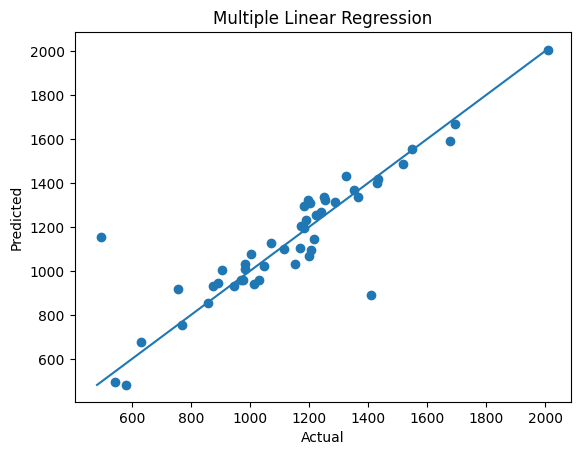

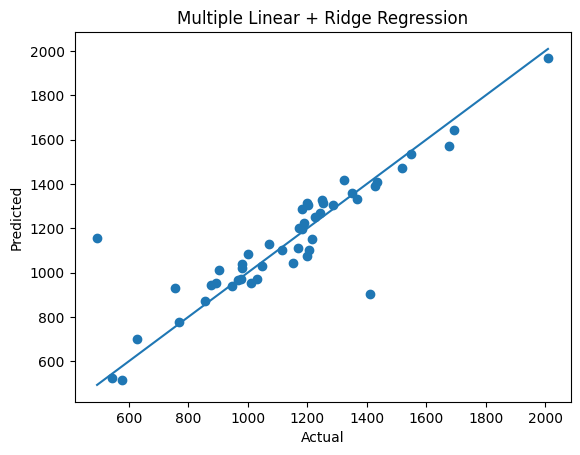

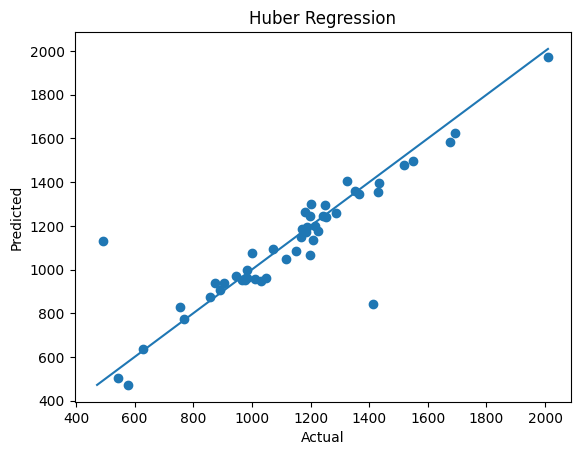

In [ ]:
#Visualisasi Actual vs Predicted
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)

    # garis ideal
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.show()

plot_actual_vs_pred(y_test, y_pred_lr, "Multiple Linear Regression")
plot_actual_vs_pred(y_test, y_pred_ridge, "Multiple Linear + Ridge Regression")
plot_actual_vs_pred(y_test, y_pred_huber_tuned, "Huber Regression")

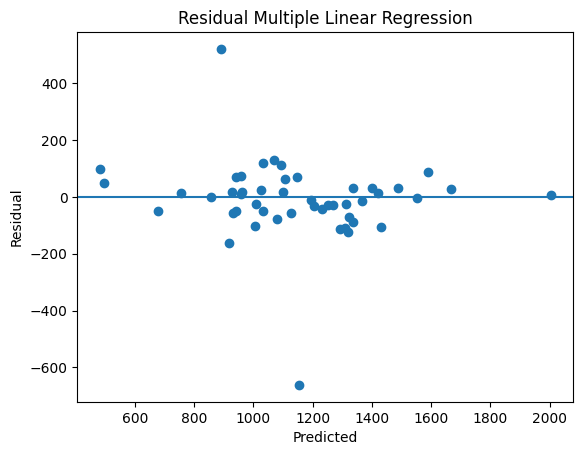

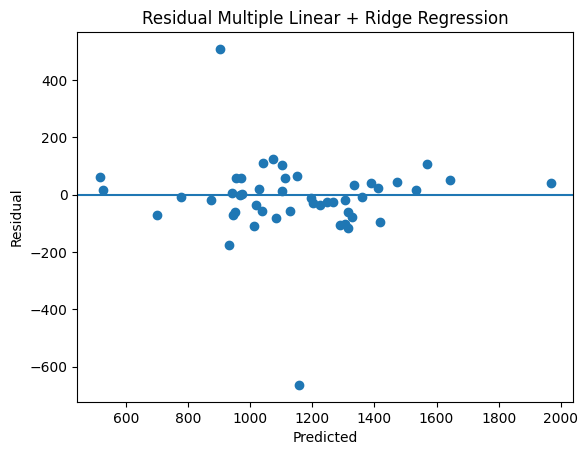

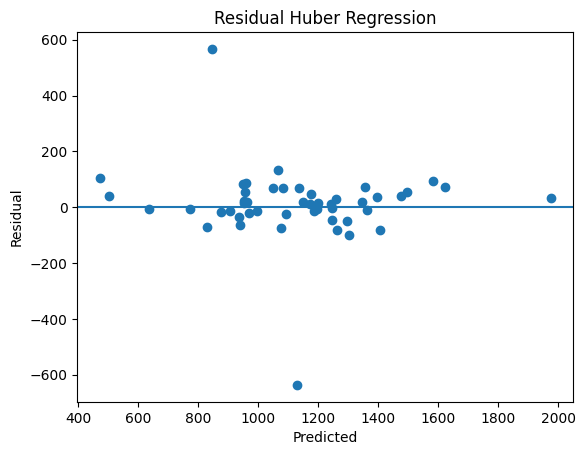

In [ ]:
#Visualisasi Residual Plot
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0)
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(title)
    plt.show()

# Plot residual semua model
plot_residuals(y_test, y_pred_lr, "Residual Multiple Linear Regression")
plot_residuals(y_test, y_pred_ridge, "Residual Multiple Linear + Ridge Regression")
plot_residuals(y_test, y_pred_huber_tuned, "Residual Huber Regression")

**Interpretasi Hasil + Visualisasi**
1. Hasil Multiple Linear Regression : Seperti yang terlihat pada evaluasi diatas model ini menghasilkan nilai eror (MAE dan RMSE) yang paling tinggi dan skor R2 yang paling rendah dibandingkan model lainnya Tingginya eror dan rendahnya R2 menunjukkan bahwa asumsi "hubungan garis lurus" yang digunakan oleh Regresi Linier tidak mampu menjelaskan variansi data dengan baik.
2. Hasil Multiple Linear Regression + Ridge : Seperti yang terlihat pada evaluasi diatas model ini menghasilkan nilai eror (MAE dan RMSE) lebih kecil dari MLR namun kurang dari Huber dan skor R2 diantara model lainnya. Regularisasi membantu mengurangi overfitting. Sehingga, model ini lebih baik daripada Multiple Linear Regression.
3. Hasil Huber Regresssion : Seperti yang terlihat pada evaluasi diatas model ini menghasilkan nilai eror (MAE dan RMSE) yang paling rendah dan skor R2 yang paling tinggi dibandingkan model lainnya. Hal ini mengindikasikan bahwa model ini paling robust terhadap outlier, memberikan error yang paling minimum dan memiliki RMSE lebih kecil dibanding model lainnya.

## **Analysis**

1. Model mana yang lebih baik?
Berdasarkan hasil matriks evaluasi diatas dengan hasil :

- Multiple Linear Regression->
MAE: 77.23
MSE: 19203.94
RMSE: 138.58
R²: 0.7826

- Ridge Regression->
MAE: 76.84
MSE: 18928.19
RMSE: 137.58
R²: 0.7857

- Huber Regression->
MAE: 68.15
MSE: 18058.78
RMSE: 134.38
R²: 0.7956

  Dapat terlihat bahwa MAE (error rata-rata) : Huber paling kecil (68.15), RMSE (sensitif terhadap error besar) : Huber paling kecil (134.38), R² (kemampuan menjelaskan variasi data) : Huber paling tinggi (0.7956)

  Hal ini menyimpulkan bahwa **Huber Regression** adalah model terbaik diantara ketiganya.

  Karena memiliki error paling rendah di semua metrik utama, emiliki R² tertinggi, artinya mampu menjelaskan variasi harga rumah lebih baik, lebih stabil terhadap data ekstrem dibanding model lain.

2. Bagaimana pengaruh outlier terhadap model linier?
Model Linear Regression menunjukkan: RMSE relatif tinggi (138.58) yang artinya performa lebih buruk dibanding penggunaan Ridge dan model Huber.
Hal ini terjadi karena
Linear Regression menggunakan pendekatan Ordinary Least Squares (OLS) dan OLS meminimalkan kuadrat error (MSE). Sehingga dampak pada model adalah koefisien model menjadi bias, prediksi menjadi tidak akurat, serta RMSE meningkat.

3. Mengapa Huber lebih robust?
Karena Huber Regression menggunakan Huber Loss Function, yang menggabungkan:
MSE (kuadrat error) untuk error kecil dan MAE (linear error) untuk error besar. Yang artinya ketika menghadapi data normal akan diberlakukan linear regression, namun ketika menemukan outlier, maka tidak akan diberi pinalti berlebihan. Seperti yang terlihat RMSE Huber (134.38) < Linear (138.58), MAE Huber jauh lebih kecil (68.15 vs 77.23), R² lebih tinggi. Sehingga Huber lebih robust karena mengurangi pengaruh outlier ekstrem, menghasilkan model yang lebih stabil, memberikan performa prediksi yang lebih baik secara keseluruhan.

## **Conclusion**

**Kesimpulan**

Berdasarkan hasil evaluasi terhadap tiga model regresi, yaitu Linear Regression, Linear + Ridge Regression, dan Huber Regression, dapat disimpulkan bahwa:
Model Huber Regression memberikan performa terbaik dibandingkan model lainnya
Huber memiliki:
MAE paling rendah (68.15) -> menunjukkan rata-rata error paling kecil
RMSE paling rendah (134.38) -> lebih baik dalam menangani error besar
R² paling tinggi (0.7956) -> mampu menjelaskan variasi data paling baik

Selain itu, hasil analisis menunjukkan bahwa dataset mengandung outlier, yang berdampak negatif terhadap performa model Linear Regression. Model Linear dan Linear + Ridge masih terpengaruh oleh outlier, sedangkan Huber mampu mengurangi pengaruh tersebut.

**Rekomendasi Model**

Berdasarkan hasil analisis dan evaluasi, direkomendasikan untuk menggunakan Huber Regression dalam memprediksi harga rumah pada dataset ini.

Alasan utama:
1. Lebih robust terhadap outlier, sehingga menghasilkan prediksi yang lebih stabil
2. Memberikan nilai error yang lebih kecil dibandingkan model lain
3. Memiliki kemampuan generalisasi yang lebih baik (ditunjukkan oleh R² tertinggi)

# **Regresi Non Linear**

## **Deskripsi Kasus**

**Konteks:** Pengelola gedung ingin memprediksi konsumsi energi harian berdasarkan berbagai faktor operasional dan kondisi lingkungan. Konsumsi energi ini sangat penting untuk efisiensi biaya dan pengelolaan sumber daya. Namun, hubungan antara variabel input dan konsumsi energi tidak selalu linier, sehingga dibutuhkan pendekatan model yang mampu menangkap pola yang lebih kompleks.

**Variabel:** Berdasarkan dataset yang diberikan, variabel independen (fitur) yang digunakan sebagai prediktor meliputi faktor-faktor seperti suhu lingkungan, kelembaban, jumlah penghuni gedung, waktu operasional, serta variabel lain yang berkaitan dengan kondisi operasional dan lingkungan gedung.
Sedangkan variabel dependen (target) yang akan diprediksi adalah konsumsi energi dalam kWh.

**Tujuan:** Analisis ini memiliki beberapa tujuan utama, yaitu:
1. Memahami keterbatasan model regresi linier dalam menangkap hubungan non-linear
2. Membangun model non-linear seperti MLP Regressor dan RBF Regression
3. Membandingkan performa model linier dan non-linier dalam memprediksi konsumsi energi

**Tantangan Utama:** Tantangan terbesar dalam kasus ini adalah adanya pola hubungan non-linear antara variabel input dan target. Model regresi linier cenderung tidak mampu menangkap pola kompleks ini sehingga menghasilkan prediksi yang kurang akurat.
Selain itu, kemungkinan terdapat:
1. Variasi data yang tinggi (fluktuasi konsumsi energi)
2. Interaksi antar variabel yang kompleks
3. Potensi outlier atau noise pada data sensor

Hal ini menuntut penggunaan model yang lebih fleksibel dan robust agar dapat menghasilkan prediksi yang lebih baik.

## **Exploratory Data Analysis (EDA)**

**Deskripsi Database**

Nama Database : dataset_regresi_nonlinier_energi.csv

In [ ]:
#Load Database
#Upload Dataset Ke Google Colab
df1 = pd.read_csv('dataset_regresi_nonlinier_energi.csv')

##Cek Statistik Deskriptif
df1.describe()

,suhu_rata_rata_c,kelembaban_persen,jumlah_penghuni,jam_operasional_ac,hari_kerja,luas_area_m2,energi_harian_kwh
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,29.850154,67.736115,136.496154,10.116962,0.734615,1440.000000,376.441692
std,4.703787,13.190309,71.040936,3.595669,0.442389,373.979951,123.225514
min,22.000000,45.090000,21.000000,4.000000,0.000000,800.000000,147.790000
25%,25.742500,56.417500,72.000000,6.967500,0.000000,1200.000000,275.720000
50%,29.515000,68.820000,137.500000,10.095000,1.000000,1600.000000,358.380000
75%,34.082500,78.795000,197.250000,13.280000,1.000000,1600.000000,456.415000
max,37.950000,89.990000,259.000000,15.940000,1.000000,2000.000000,755.250000


In [ ]:
#Cek Missing Value
df1.isnull().sum()

,0
id_hari,0
suhu_rata_rata_c,0
kelembaban_persen,0
jumlah_penghuni,0
jam_operasional_ac,0
hari_kerja,0
luas_area_m2,0
energi_harian_kwh,0


In [ ]:
#Cek Statistik Outlier
target = 'energi_harian_kwh'

Q1 = df1[target].quantile(0.25)
Q3 = df1[target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df1[(df1[target] < lower_bound) |
              (df1[target] > upper_bound)]

print("Jumlah outlier:", len(outliers))
print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

Jumlah outlier: 2
Batas bawah: 4.677500000000123
Batas atas: 727.4574999999999


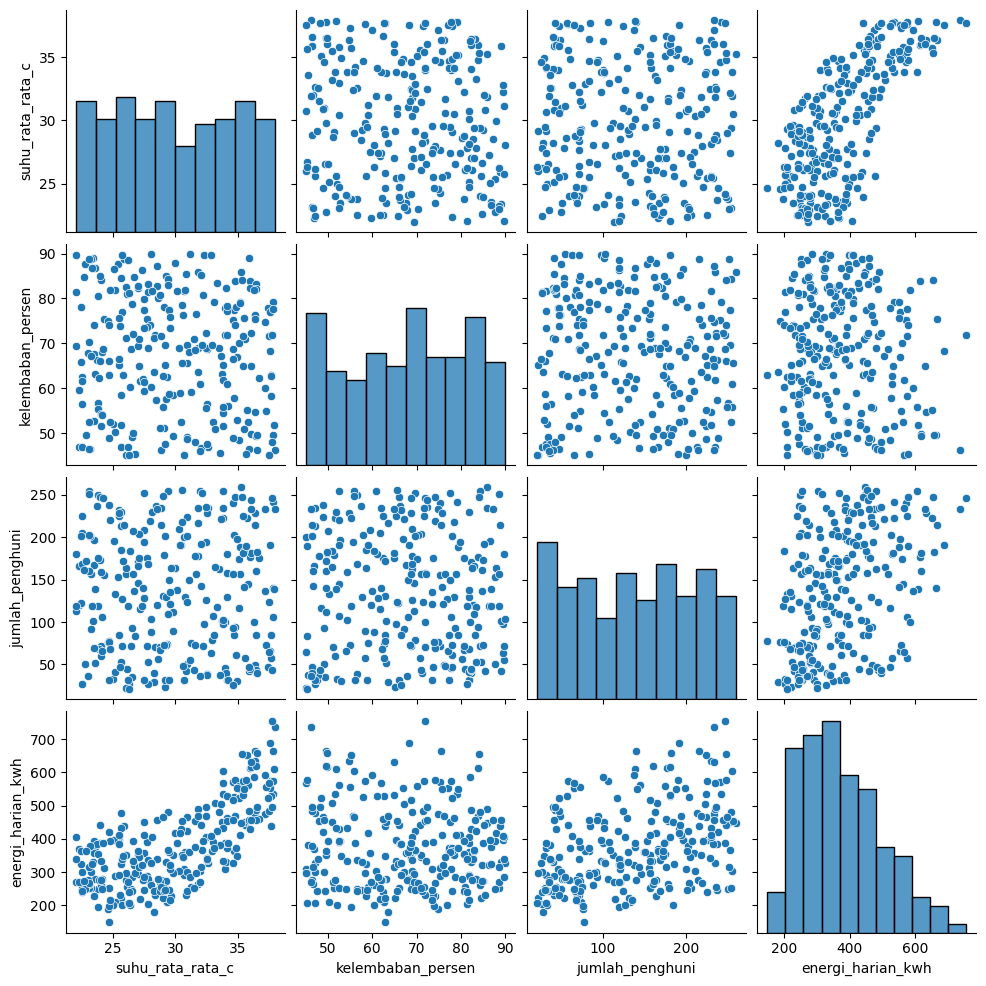

In [ ]:
cols = ['suhu_rata_rata_c', 'kelembaban_persen', 'jumlah_penghuni', 'energi_harian_kwh']  # sesuaikan
sns.pairplot(df1[cols])
plt.show()

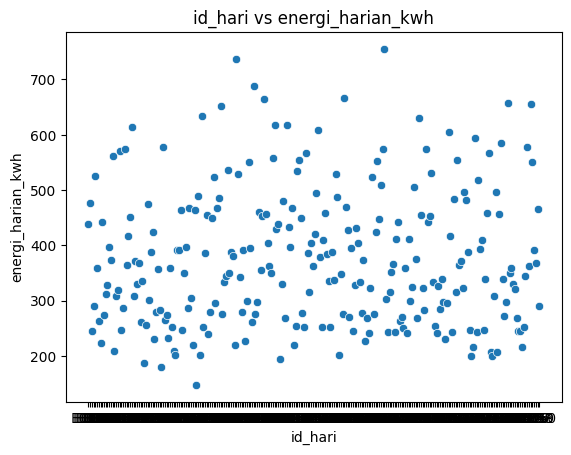

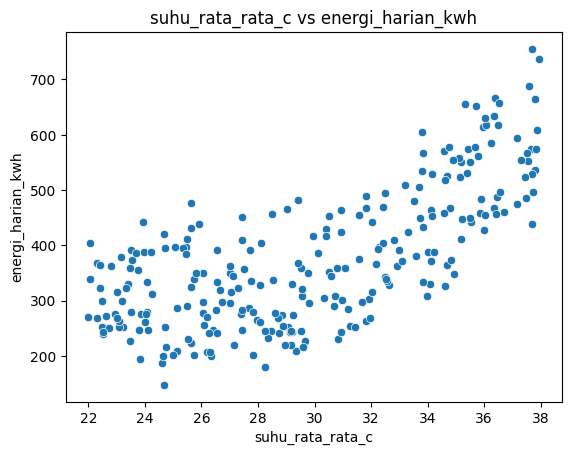

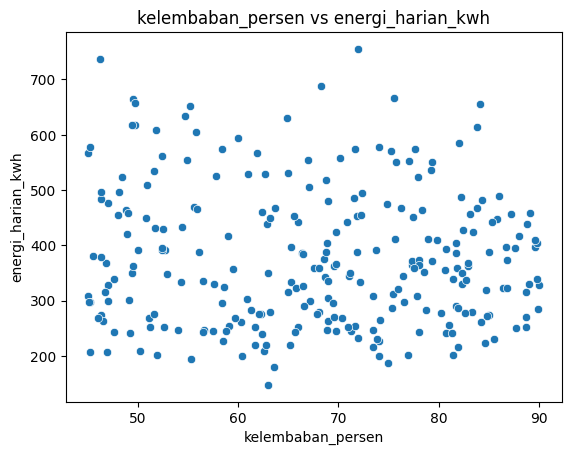

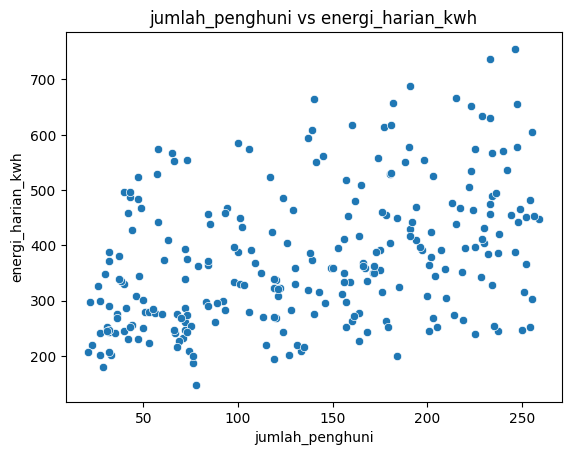

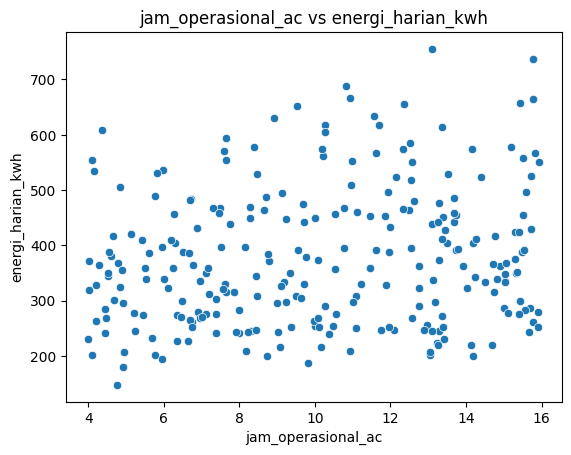

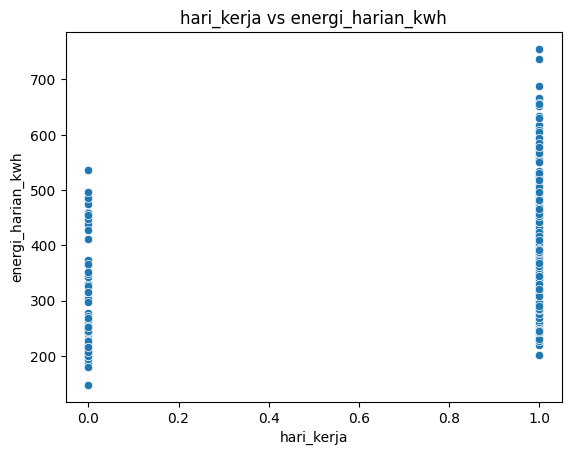

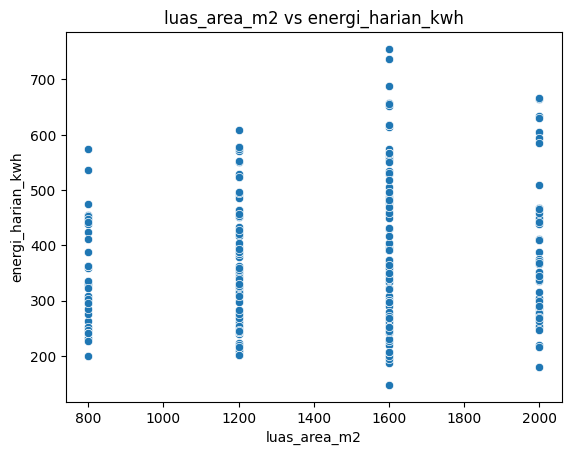

In [ ]:
target = 'energi_harian_kwh'  # sesuaikan dengan nama kolom

for col in df1.columns:
    if col != target:
        plt.figure()
        sns.scatterplot(x=df1[col], y=df1[target])
        plt.title(f'{col} vs {target}')
        plt.show()

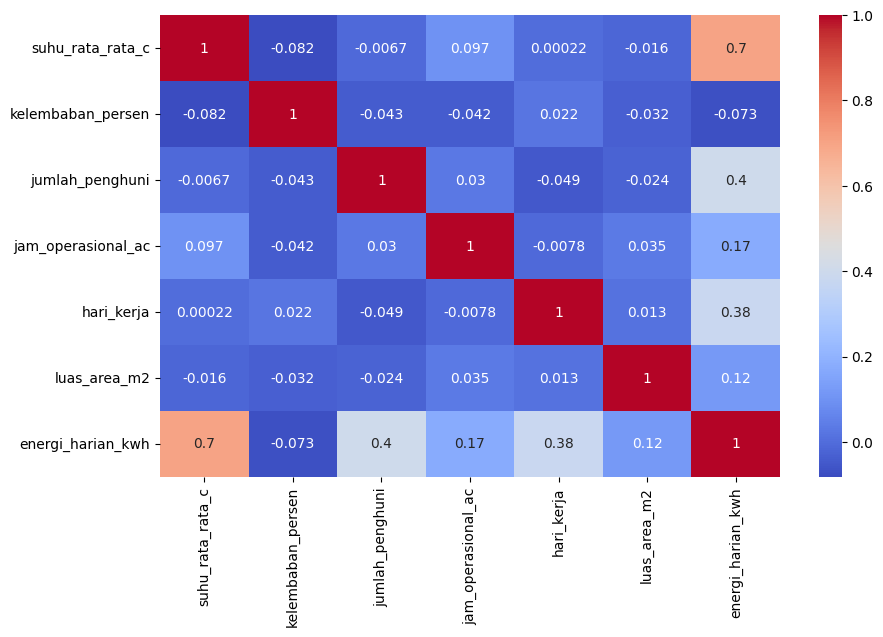

In [ ]:
df_numeric = df1.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

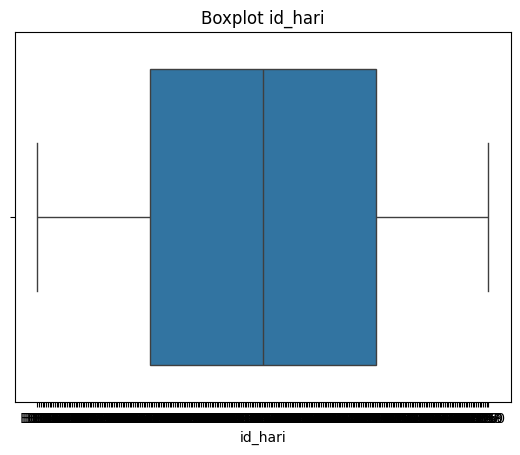

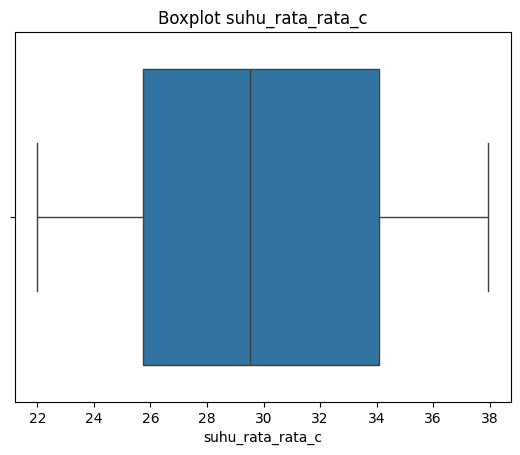

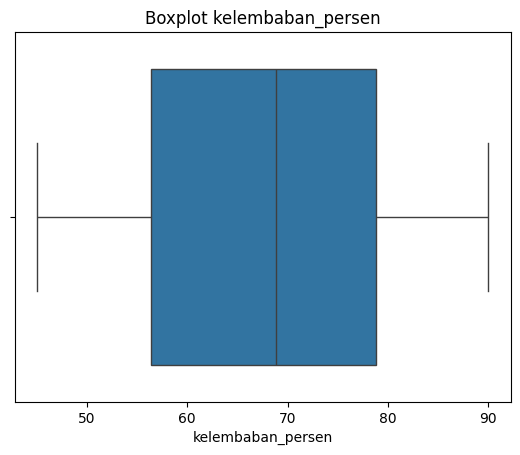

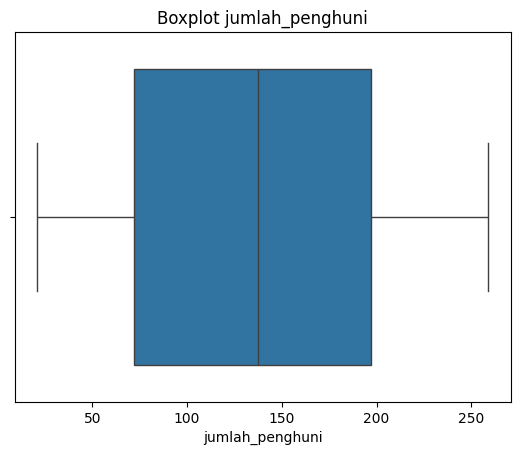

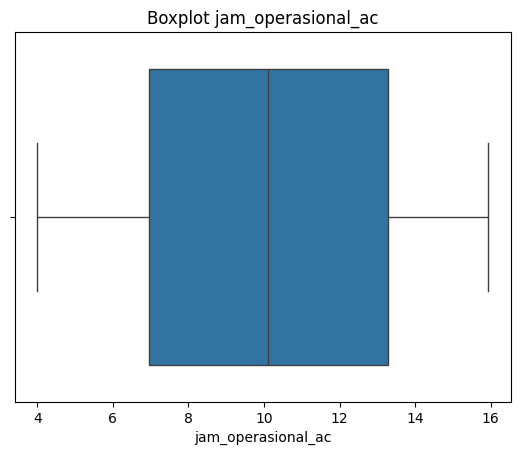

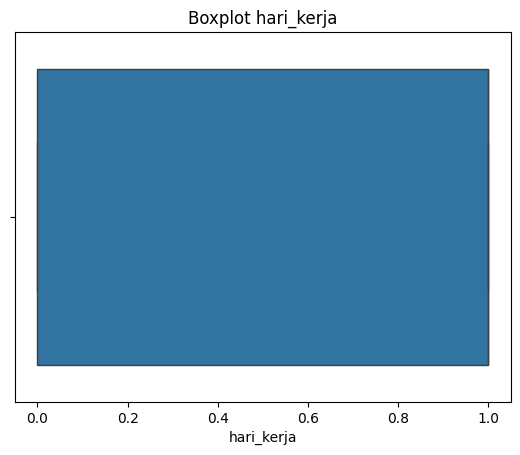

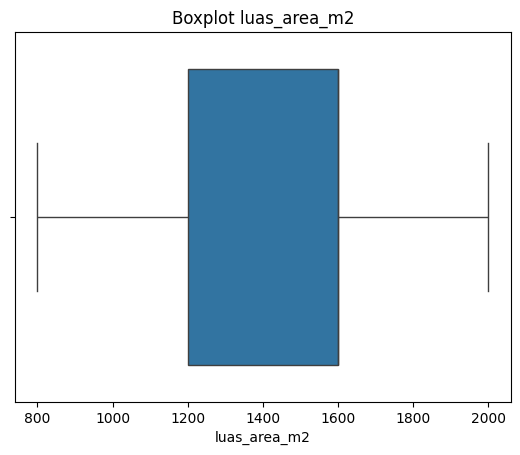

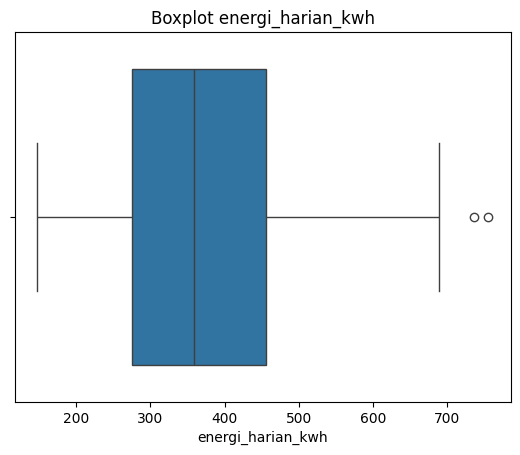

In [ ]:
for col in df1.columns:
    plt.figure()
    sns.boxplot(x=df1[col])
    plt.title(f'Boxplot {col}')
    plt.show()

**Analisis Identifikasi Pola Non Linear**
Dari visualisasi scatter plot, terlihat bahwa hubungan antara beberapa variabel dengan konsumsi energi tidak membentuk garis lurus, melainkan pola melengkung. Hal ini menunjukkan bahwa hubungan antar variabel bersifat non-linear, sehingga model linier kemungkinan tidak cukup untuk menangkap pola tersebut.

**Insight EDA**

a. Deskripsi : Terdapat 260 data, dengan 8 fitur yaitu,
1. id_hari
2. suhu_rata_rata_c
3. kelembaban_persen
4. jumlah_penghuni
5. jam_operasional_ac
6. hari_kerja
7. luas_area_m2
8. energi_harian_kwh

b. Tidak ada Missing Value yang terdeteksi

c. Hubungan (Korelasi) antar Fitur
1. Dari semua scatter plot yang ada, suhu_rata_rata_c memiliki korelasi yang paling jelas dan kuat, sekaligus paling menunjukkan sifat non-linear.

  Analisis Visual: Anda bisa melihat bahwa seiring naiknya suhu, penggunaan energi ikut naik. Namun, kenaikannya tidak membentuk garis lurus yang konstan. Terlihat ada pola eksponensial atau lengkungan (kurva) ke atas.

2. Variabel Diskrit & Kategorikal: luas_area_m2 & hari_kerja

  Kedua variabel ini tidak bersifat kontinu (mengalir), melainkan mengelompok pada nilai-nilai tertentu.

  hari_kerja: Terbagi jelas menjadi 0 (libur) dan 1 (masuk). Terlihat bahwa distribusi penggunaan energi pada hari kerja (1) jauh lebih bervariasi dan bisa mencapai titik maksimal yang jauh lebih tinggi (>700 kWh) dibandingkan hari libur.

  luas_area_m2: Datanya mengelompok di angka 800, 1200, 1600, dan 2000. Meskipun variance (sebaran) di setiap kelompok sangat lebar, batas atas penggunaan energi cenderung sedikit meningkat seiring bertambahnya luas area.

## **Preprocessing**

In [ ]:
#Menentukan target
target = 'energi_harian_kwh'

#Menentukan Fitur
X = df1.drop(columns=[target])
y = df1[target]

print("Fitur:", X.columns)
print("Target:", target)

Fitur: Index(['id_hari', 'suhu_rata_rata_c', 'kelembaban_persen', 'jumlah_penghuni',
       'jam_operasional_ac', 'hari_kerja', 'luas_area_m2'],
      dtype='object')
Target: energi_harian_kwh


In [ ]:
# Ambil hanya kolom numerik
X_numeric = X.select_dtypes(include=['int64', 'float64'])

# Kalau mau cek kolom yang dibuang
X_categorical = X.select_dtypes(exclude=['int64', 'float64'])

print("Numerik:", X_numeric.columns)
print("Kategori:", X_categorical.columns)

Numerik: Index(['suhu_rata_rata_c', 'kelembaban_persen', 'jumlah_penghuni',
       'jam_operasional_ac', 'hari_kerja', 'luas_area_m2'],
      dtype='object')
Kategori: Index(['id_hari'], dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y,
    test_size=0.2,
    random_state=42
)
print("Jumlah data train:", len(X_train))
print("Jumlah data test:", len(X_test))

Jumlah data train: 208
Jumlah data test: 52


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Analysis Preprocessing**
1. Variabel target dipisahkan dari fitur agar model dapat belajar hubungan antara fitur dan target = 'energi_harian_kwh'. Semua variabel selain target digunakan sebagai prediktor dalam model.
2. Data dibagi menjadi data training dan testing dengan rasio 80:20. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya. Penggunaan random_state 42 bertujuan agar hasil pembagian data konsisten.
3. Standardisasi dilakukan untuk menyamakan skala antar fitur dengan mengubah data sehingga memiliki mean 0 dan standar deviasi 1. Hal ini penting agar proses pembelajaran menjadi lebih stabil dan tidak bias terhadap fitur dengan skala besar.
Proses scaling hanya dilakukan fit pada data training untuk menghindari data leakage.
4. Tidak semua variabel dapat langsung digunakan dalam proses modeling. Variabel bertipe kategorikal seperti ID gedung tidak memiliki makna numerik sehingga tidak dapat diproses oleh algoritma yang membutuhkan input numerik, seperti StandardScaler dan model regresi.
Oleh karena itu, hanya variabel numerik yang digunakan dalam proses scaling dan modeling. Variabel kategorikal diabaikan atau dapat dilakukan encoding jika memiliki informasi yang relevan.
Hal ini juga bertujuan untuk menghindari error serta memastikan bahwa model dapat belajar dari data yang bermakna secara numerik.

## **Modeling**

###**Linear Regression**

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

###**MLP Regression**

In [ ]:
mlp = MLPRegressor(max_iter=1000, random_state=42)

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(
    mlp,
    param_grid_mlp,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_mlp.fit(X_train_scaled, y_train)

best_mlp = grid_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_scaled)

print("Best MLP Params:", grid_mlp.best_params_)

Best MLP Params: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}


###**RBF Regression**

In [ ]:
svr = SVR(kernel='rbf')

param_grid_svr = {
    'C': [1, 10, 100],
    'gamma': ['scale', 0.1, 0.01],
    'epsilon': [0.1, 0.2]
}

grid_svr = GridSearchCV(
    svr,
    param_grid_svr,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_svr.fit(X_train_scaled, y_train)

best_svr = grid_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test_scaled)

print("Best SVR Params:", grid_svr.best_params_)

Best SVR Params: {'C': 100, 'epsilon': 0.2, 'gamma': 0.1}


**Analisis Modeling**

Pada tahap modeling, digunakan tiga pendekatan yaitu Linear Regression sebagai baseline, serta dua model non-linear yaitu MLP Regressor dan RBF Regression.

Linear Regression digunakan sebagai baseline untuk melihat performa model sederhana dalam menangkap hubungan data. Model ini mengasumsikan hubungan linear antar variabel.

MLP Regressor digunakan karena mampu menangkap hubungan non-linear melalui hidden layer dan fungsi aktivasi. Hyperparameter tuning dilakukan untuk menemukan kombinasi parameter terbaik agar performa model optimal.

RBF Regression (melalui SVR dengan kernel RBF) digunakan karena mampu menangkap pola non-linear dengan memetakan data ke dimensi yang lebih tinggi. Parameter seperti C dan gamma sangat memengaruhi fleksibilitas model sehingga perlu dilakukan tuning.

Untuk meningkatkan performa model non-linear, dilakukan hyperparameter tuning menggunakan GridSearchCV sehingga diperoleh parameter terbaik yang menghasilkan error minimum.

## **Evaluation**

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print()

    return mae, mse, rmse, r2

eval_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
eval_mlp = evaluate_model(y_test, y_pred_mlp, "MLP Regressor")
eval_svr = evaluate_model(y_test, y_pred_svr, "RBF (SVR)")

Linear Regression
MAE : 34.64233506730018
MSE : 1659.756541264324
RMSE: 40.74010973554593
R2  : 0.9003849556273564

MLP Regressor
MAE : 15.829247228478945
MSE : 340.24547372276896
RMSE: 18.445744054463322
R2  : 0.979579193020281

RBF (SVR)
MAE : 17.447556692073455
MSE : 528.0751975551913
RMSE: 22.97988680466445
R2  : 0.9683060539731438



In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'MLP Regressor', 'RBF (SVR)'],
    'MAE': [eval_lr[0], eval_mlp[0], eval_svr[0]],
    'MSE': [eval_lr[1], eval_mlp[1], eval_svr[1]],
    'RMSE': [eval_lr[2], eval_mlp[2], eval_svr[2]],
    'R2': [eval_lr[3], eval_mlp[3], eval_svr[3]]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,34.642335,1659.756541,40.740110,0.900385
1,MLP Regressor,15.829247,340.245474,18.445744,0.979579
2,RBF (SVR),17.447557,528.075198,22.979887,0.968306


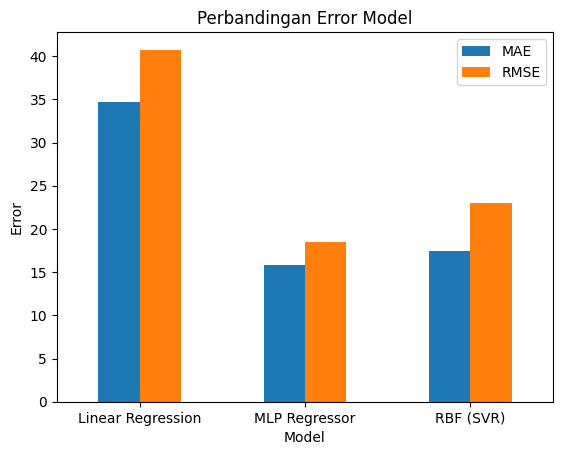

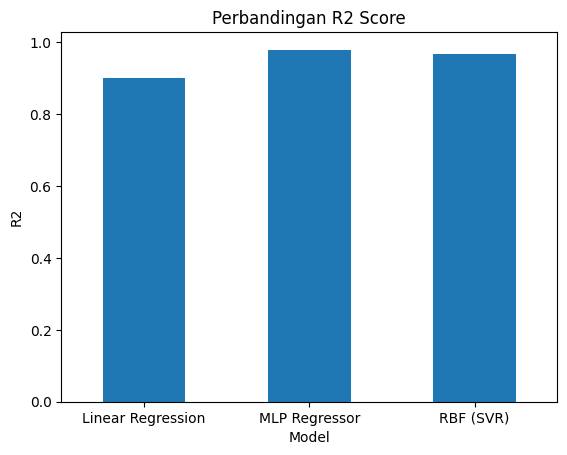

In [ ]:
results.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar')
plt.title('Perbandingan Error Model')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.show()

results.set_index('Model')['R2'].plot(kind='bar')
plt.title('Perbandingan R2 Score')
plt.ylabel('R2')
plt.xticks(rotation=0)
plt.show()

**Evaluasi Per Model**
1. Linear Regression : Berdasarkan hasil evaluasi, model Linear Regression menghasilkan nilai MAE sebesar 34.64 dan RMSE sebesar 40.74, yang menunjukkan bahwa rata-rata kesalahan prediksi masih cukup besar. Nilai R² sebesar 0.90 memang tergolong tinggi, namun jika dibandingkan dengan model lain, performanya masih lebih rendah. Hal ini mengindikasikan bahwa model linier belum mampu menangkap seluruh pola dalam data dengan baik.

2. MLP Regressor : Model MLP Regressor menunjukkan performa terbaik dengan nilai MAE sebesar 15.83 dan RMSE sebesar 18.45, yang jauh lebih rendah dibandingkan model lainnya. Selain itu, nilai R² sebesar 0.98 menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi dalam data. Hal ini menandakan bahwa MLP sangat efektif dalam menangkap pola hubungan antar variabel.

3. RBF (SVR) : Model RBF (SVR) juga menunjukkan performa yang sangat baik dengan nilai MAE sebesar 17.45 dan RMSE sebesar 22.98. Nilai R² sebesar 0.97 menunjukkan bahwa model mampu menjelaskan sebagian besar variasi data, meskipun sedikit di bawah MLP Regressor.

## **Analysis**

1. Apakah model non-linear lebih baik?
Ya, model non-linear terbukti lebih baik dibandingkan model linear pada kasus ini.

  Secara kuantitatif:

    Linear Regression ->
    MAE: 34.64
    RMSE: 40.74
    R²: 0.90

    MLP Regressor ->
    MAE: 15.83 (↓ 54% lebih kecil dari linear)
    RMSE: 18.45 (↓ ~55%)
    R²: 0.98 (↑ signifikan)

    RBF (SVR) ->
    MAE: 17.45
    RMSE: 22.98
    R²: 0.97

  Hal ini dapat dilihat dari hasil evaluasi, di mana MLP Regressor dan RBF (SVR) memiliki nilai MAE, MSE, dan RMSE yang jauh lebih rendah dibandingkan Linear Regression. Selain itu, nilai R² pada model non-linear juga lebih tinggi (mendekati 1), yang menunjukkan bahwa model mampu menjelaskan variasi data dengan lebih baik.
  Secara khusus, MLP Regressor menjadi model terbaik dengan performa paling tinggi, diikuti oleh RBF (SVR), sementara Linear Regression memiliki performa paling rendah di antara ketiganya.
    
  Model non-linear secara signifikan lebih baik karena mampu menurunkan error lebih dari 50% dan meningkatkan kemampuan prediksi secara substansial dibandingkan model linear. Hal ini menunjukkan bahwa pendekatan non-linear lebih sesuai untuk digunakan dalam kasus prediksi konsumsi energi ini.

2. Mengapa model non-linear lebih mampu menangkap pola?
Model non-linear lebih mampu menangkap pola karena tidak terbatas pada asumsi hubungan linier antar variabel. Dalam dataset ini, hubungan antara fitur dan target menunjukkan pola yang kompleks dan tidak membentuk garis lurus, sebagaimana terlihat pada tahap EDA.
Model seperti MLP Regressor menggunakan neuron dan fungsi aktivasi untuk mempelajari hubungan kompleks dan interaksi antar variabel, sehingga mampu menangkap pola non-linear yang sulit dimodelkan oleh regresi linier. Sementara itu, RBF (SVR) menggunakan kernel trick untuk memetakan data ke ruang berdimensi lebih tinggi, sehingga hubungan non-linear dalam data dapat direpresentasikan sebagai hubungan linear di ruang tersebut.
Sebaliknya, Linear Regression hanya mampu memodelkan hubungan dalam bentuk garis lurus, sehingga tidak dapat menangkap pola melengkung atau interaksi kompleks antar variabel. Akibatnya, performanya menjadi lebih rendah ketika diterapkan pada data dengan pola non-linear.


## **Conclusion**

Berdasarkan hasil evaluasi dan analisis yang telah dilakukan, model **MLP Regressor** direkomendasikan sebagai model terbaik untuk kasus prediksi konsumsi energi ini. Hal ini didasarkan pada performanya yang paling unggul dibandingkan model lainnya, dengan nilai MAE, MSE, dan RMSE yang paling rendah serta nilai R² yang paling tinggi, yaitu mendekati 1.

Keunggulan MLP Regressor terletak pada kemampuannya dalam menangkap hubungan non-linear yang kompleks antar variabel melalui arsitektur neural network dan fungsi aktivasi. Hal ini terbukti dari hasil visualisasi di mana prediksi model sangat mendekati nilai aktual, serta distribusi residual yang acak di sekitar nol.

Penggunaan model non-linear seperti MLP Regressor sangat direkomendasikan untuk menghasilkan prediksi yang lebih akurat dan optimal.

#**Penggunaan AI**
Dalam pengerjaan tugas ini, saya menggunakan bantuan AI
untuk:
1. Membantu memahami konsep regresi linier dan non-linier
2. Membantu menangani error ketika menyusun struktur kode (EDA, preprocessing, modeling, evaluation)

Seluruh kode dan analisis telah saya pahami dan sesuaikan kembali dengan dataset serta konteks tugas yang diberikan.